# Análise de distribuições — equipamentos de resultado fraco

Foco nos equipamentos cujo modelo **não ficou bom** (B-0302C, B-4703.24001B) + o B-4064A como
caso de **mudança de regime**. Para cada um, testa a hipótese de **duas distribuições**:

1. **Desligado vs. ligado** — cluster de valores baixos (parado) separado do regime de operação.
2. **Mudança de regime no tempo** — patamar normal se desloca entre anos.

Leitura prática: se a maior parte das leituras válidas é "desligado", quase não há sinal de
operação para o modelo aprender → resultado fraco. Filtrar o estado desligado (`filter_threshold`)
e/ou re-baselinar tende a ajudar.

> Notas de robustez: sensores **mortos** (constantes, ex.: fases de corrente zeradas) são
> descartados; o **% desligado** é medido entre as **leituras válidas** (ignora NaN).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from transpetro_modelos.data.loading import load_equipment_data

# equipamentos a analisar (chave de config, data da falha)
EQUIPS = [
    ("B-0302C",        "2024-08-30"),
    ("B-4703.24001B",  "2022-10-01"),
    ("B-4064A-prod",   "2024-08-30"),
]

def pick_activity(live):
    """Sensor de atividade entre os sensores VIVOS: corrente/vazão de maior amplitude."""
    for kw in ("corrente", "current", "vaz", "flow"):
        cand = [c for c in live.columns if kw in c.lower()]
        if cand:
            return max(cand, key=lambda c: live[c].max() - live[c].min())
    cv = (live.std() / live.mean().abs().replace(0, np.nan)).abs()
    return cv.idxmax()

In [2]:
def analisar(eq, falha):
    raw = load_equipment_data(eq, from_clearml=False).select_dtypes(include=[np.number])
    dead = [c for c in raw.columns if raw[c].std(skipna=True) == 0 or raw[c].notna().sum() == 0]
    df = raw.drop(columns=dead)
    cols = list(df.columns)
    print(f"\n{'='*70}\n{eq} — {df.shape[0]} linhas x {len(cols)} sensores vivos "
          f"({len(dead)} mortos: {dead}) | {str(df.index.min())[:10]} -> {str(df.index.max())[:10]} | falha {falha}")

    # 1) histograma por sensor (vivos)
    ncol = 3; nrow = int(np.ceil(len(cols)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3*nrow)); axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna().values, bins=80, color="steelblue", alpha=0.85)
        ax.set_title(c, fontsize=8); ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]: ax.axis("off")
    fig.suptitle(f"{eq} — histograma por sensor", y=1.002); fig.tight_layout(); plt.show()

    # 2) sensor de atividade: GMM 1 vs 2 + cutoff (vale) — % desligado entre leituras VÁLIDAS
    act = pick_activity(df); xs = df[act].dropna().values; x = xs.reshape(-1, 1)
    g1 = GaussianMixture(1, random_state=0).fit(x); g2 = GaussianMixture(2, random_state=0).fit(x)
    means = np.sort(g2.means_.ravel()); stds = np.sqrt(g2.covariances_.ravel())
    gap = abs(means[1]-means[0]) / max(stds); bimodal = (g2.bic(x) < g1.bic(x)) and (gap > 2)
    cutoff = off_frac = None
    if bimodal:
        grid = np.linspace(means[0], means[1], 500).reshape(-1, 1)
        cutoff = float(grid[np.argmin(np.exp(g2.score_samples(grid)))][0])
        off_frac = float((xs < cutoff).mean())   # entre leituras válidas (sem NaN)
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.hist(xs, bins=100, density=True, color="steelblue", alpha=0.6)
    grid = np.linspace(xs.min(), xs.max(), 1000).reshape(-1, 1)
    ax.plot(grid.ravel(), np.exp(g2.score_samples(grid)), color="darkorange", lw=2, label="GMM 2 comp.")
    if cutoff is not None: ax.axvline(cutoff, color="red", ls="--", lw=1.5, label=f"cutoff={cutoff:.3g}")
    ax.set_title(f"{eq} — sensor de atividade: {act}"); ax.set_xlabel(act); ax.legend(); fig.tight_layout(); plt.show()
    if bimodal:
        print(f"  BIMODAL: modos {means[0]:.3g} (desligado) / {means[1]:.3g} (ligado) | "
              f"cutoff {cutoff:.4g} | DESLIGADO = {off_frac:.1%} das leituras válidas")
    else:
        print(f"  unimodal em {act} (sem cluster desligado claro)")

    # 3) distribuição por ano (regime shift) — só no estado LIGADO p/ não confundir com duty cycle
    base = df[df[act] >= cutoff] if cutoff is not None else df
    anos = sorted(base.index.year.unique())
    cmap = plt.cm.viridis(np.linspace(0, 1, len(anos)))
    fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3*nrow)); axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        for ano, cor in zip(anos, cmap):
            xa = base.loc[base.index.year == ano, c].dropna().values
            if len(xa): ax.hist(xa, bins=50, density=True, histtype="step", color=cor, lw=1.3, label=str(ano))
        ax.set_title(c, fontsize=8); ax.tick_params(labelsize=7)
    for ax in axes[len(cols):]: ax.axis("off")
    axes[0].legend(fontsize=7, title="ano")
    fig.suptitle(f"{eq} — distribuição por ano (estado ligado)", y=1.002); fig.tight_layout(); plt.show()
    media = base.groupby(base.index.year).mean().T; media.columns = [str(a) for a in media.columns]
    print("  média por ano (estado ligado):"); print(media.round(2).to_string())
    return {"eq": eq, "activity": act, "bimodal": bimodal, "off_frac": off_frac, "cutoff": cutoff,
            "dead": len(dead)}


B-0302C — 319680 linhas x 7 sensores vivos (21 mortos: ['Corrente Fase A Motor', 'Corrente Fase B Motor', 'Corrente Fase C Motor', 'Corrente Terra Motor', 'Desbalac Carga Motor', 'Desbalac Corrente Motor', 'Fator de Pot Motor', 'Freq Alim Motor', 'Potência Aparente', 'Temperatura Enrolamento Motor 1', 'Temperatura Enrolamento Motor 2', 'Temperatura Enrolamento Motor 3', 'Temperatura Enrolamento Motor 4', 'Temperatura Enrolamento Motor 5', 'Temperatura Enrolamento Motor 6', 'Tensão Vab Motor', 'Tensão Van Motor', 'Tensão Vbc Motor', 'Tensão Vbn Motor', 'Tensão Vca Motor', 'Tensão Vcn Motor']) | 2024-02-01 -> 2024-09-10 | falha 2024-08-30


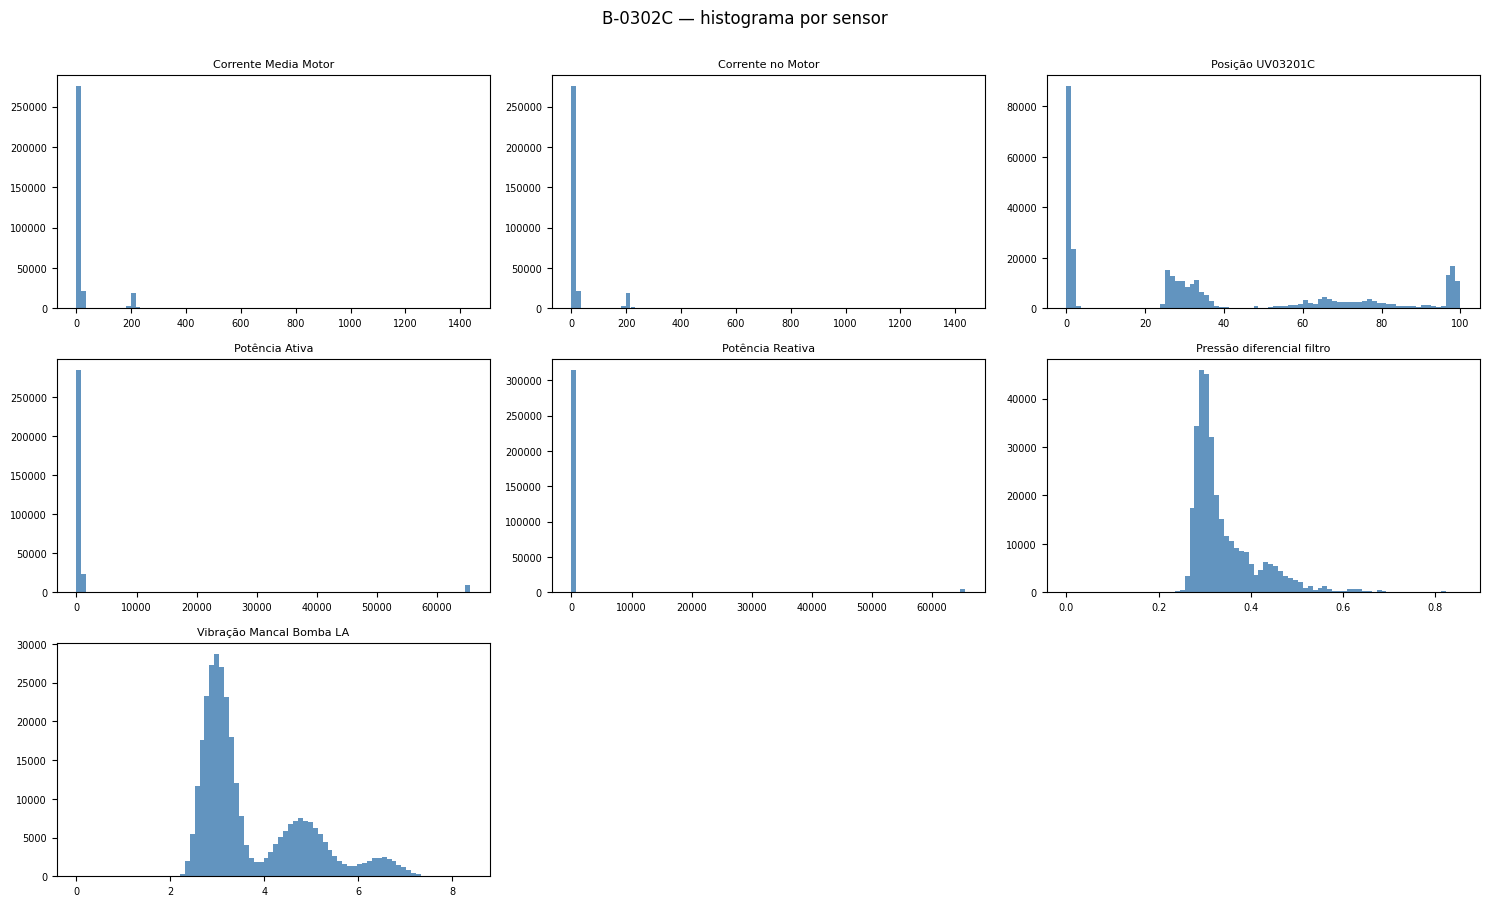

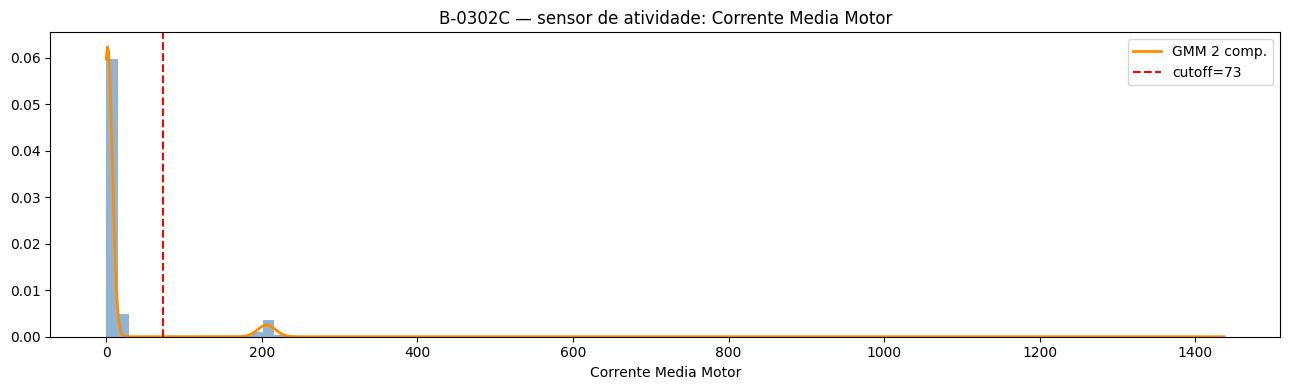

  BIMODAL: modos 1.77 (desligado) / 206 (ligado) | cutoff 72.97 | DESLIGADO = 92.8% das leituras válidas


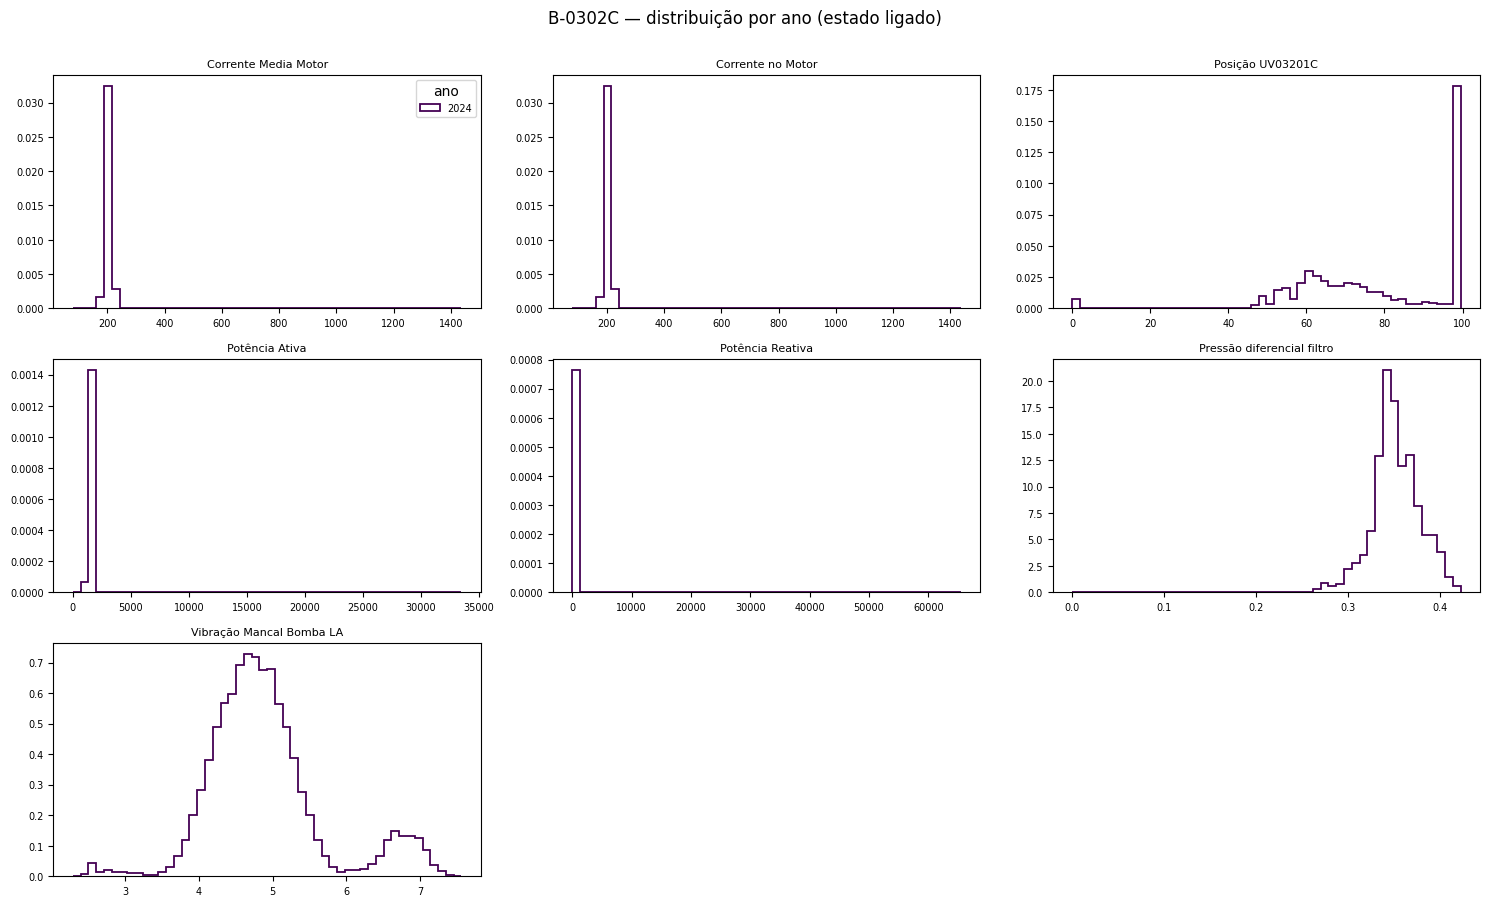

  média por ano (estado ligado):
                               2024
Descrição                          
Corrente Media Motor         205.96
Corrente no Motor            205.97
Posição UV03201C              77.64
Potência Ativa              1472.70
Potência Reativa             180.81
Pressão diferencial filtro     0.35
Vibração Mancal Bomba LA       4.90

B-4703.24001B — 400319 linhas x 15 sensores vivos (0 mortos: []) | 2022-01-27 -> 2022-10-31 | falha 2022-10-01


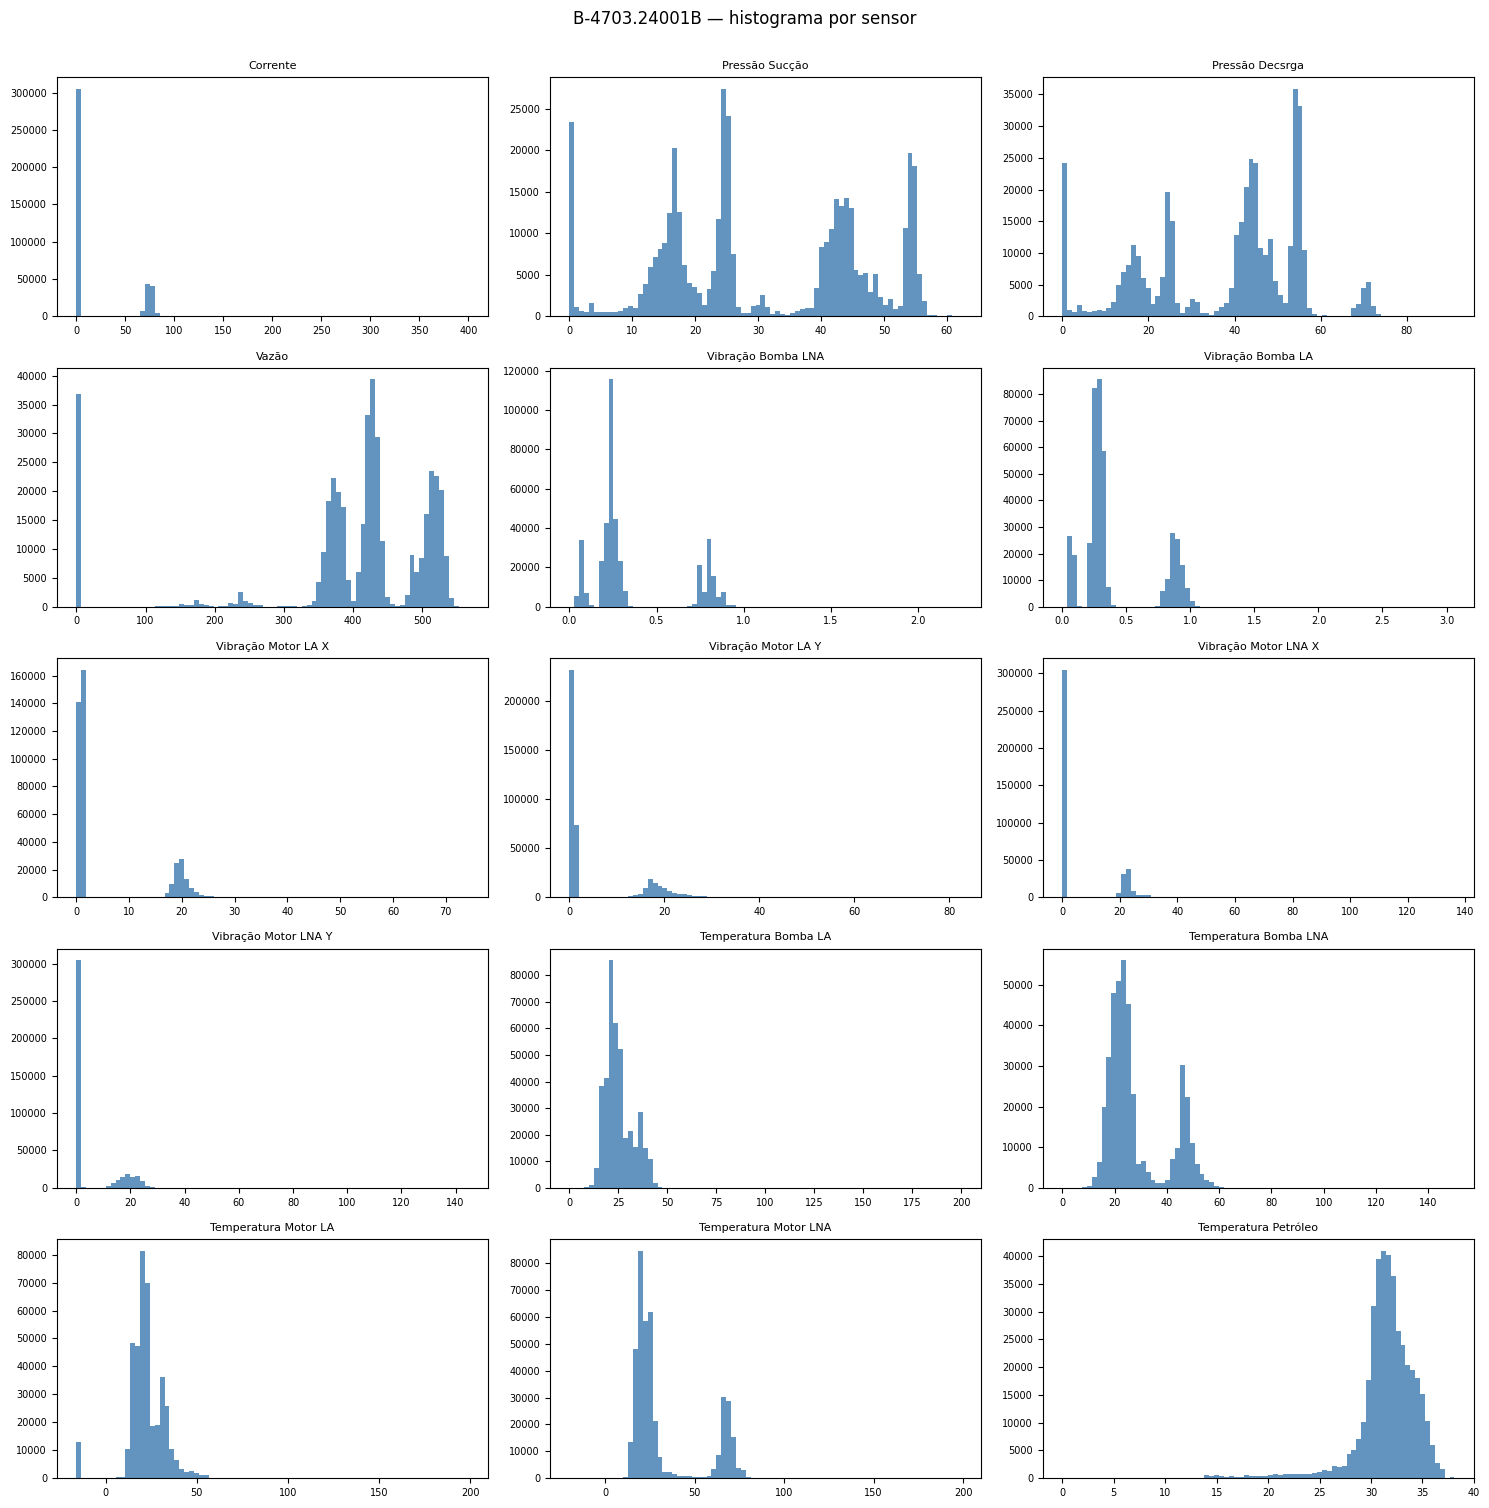

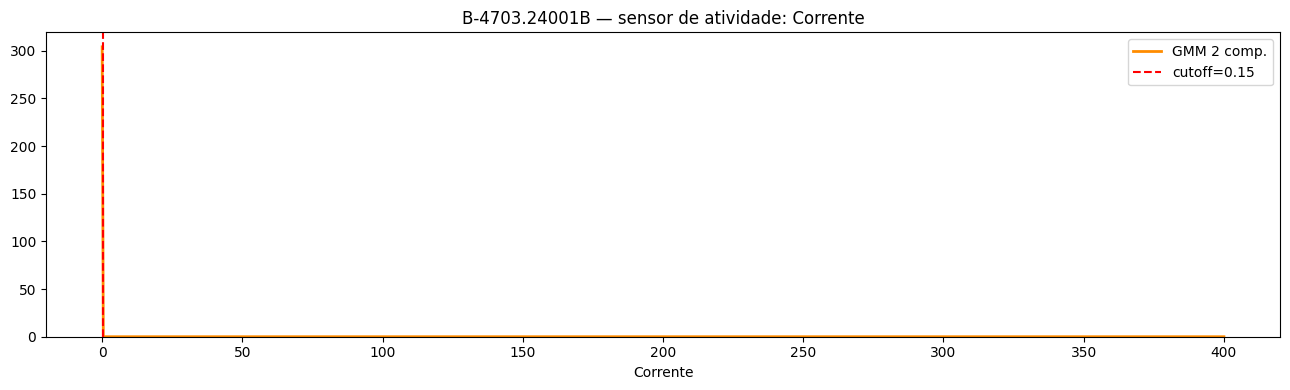

  BIMODAL: modos 0 (desligado) / 74.9 (ligado) | cutoff 0.1502 | DESLIGADO = 76.2% das leituras válidas


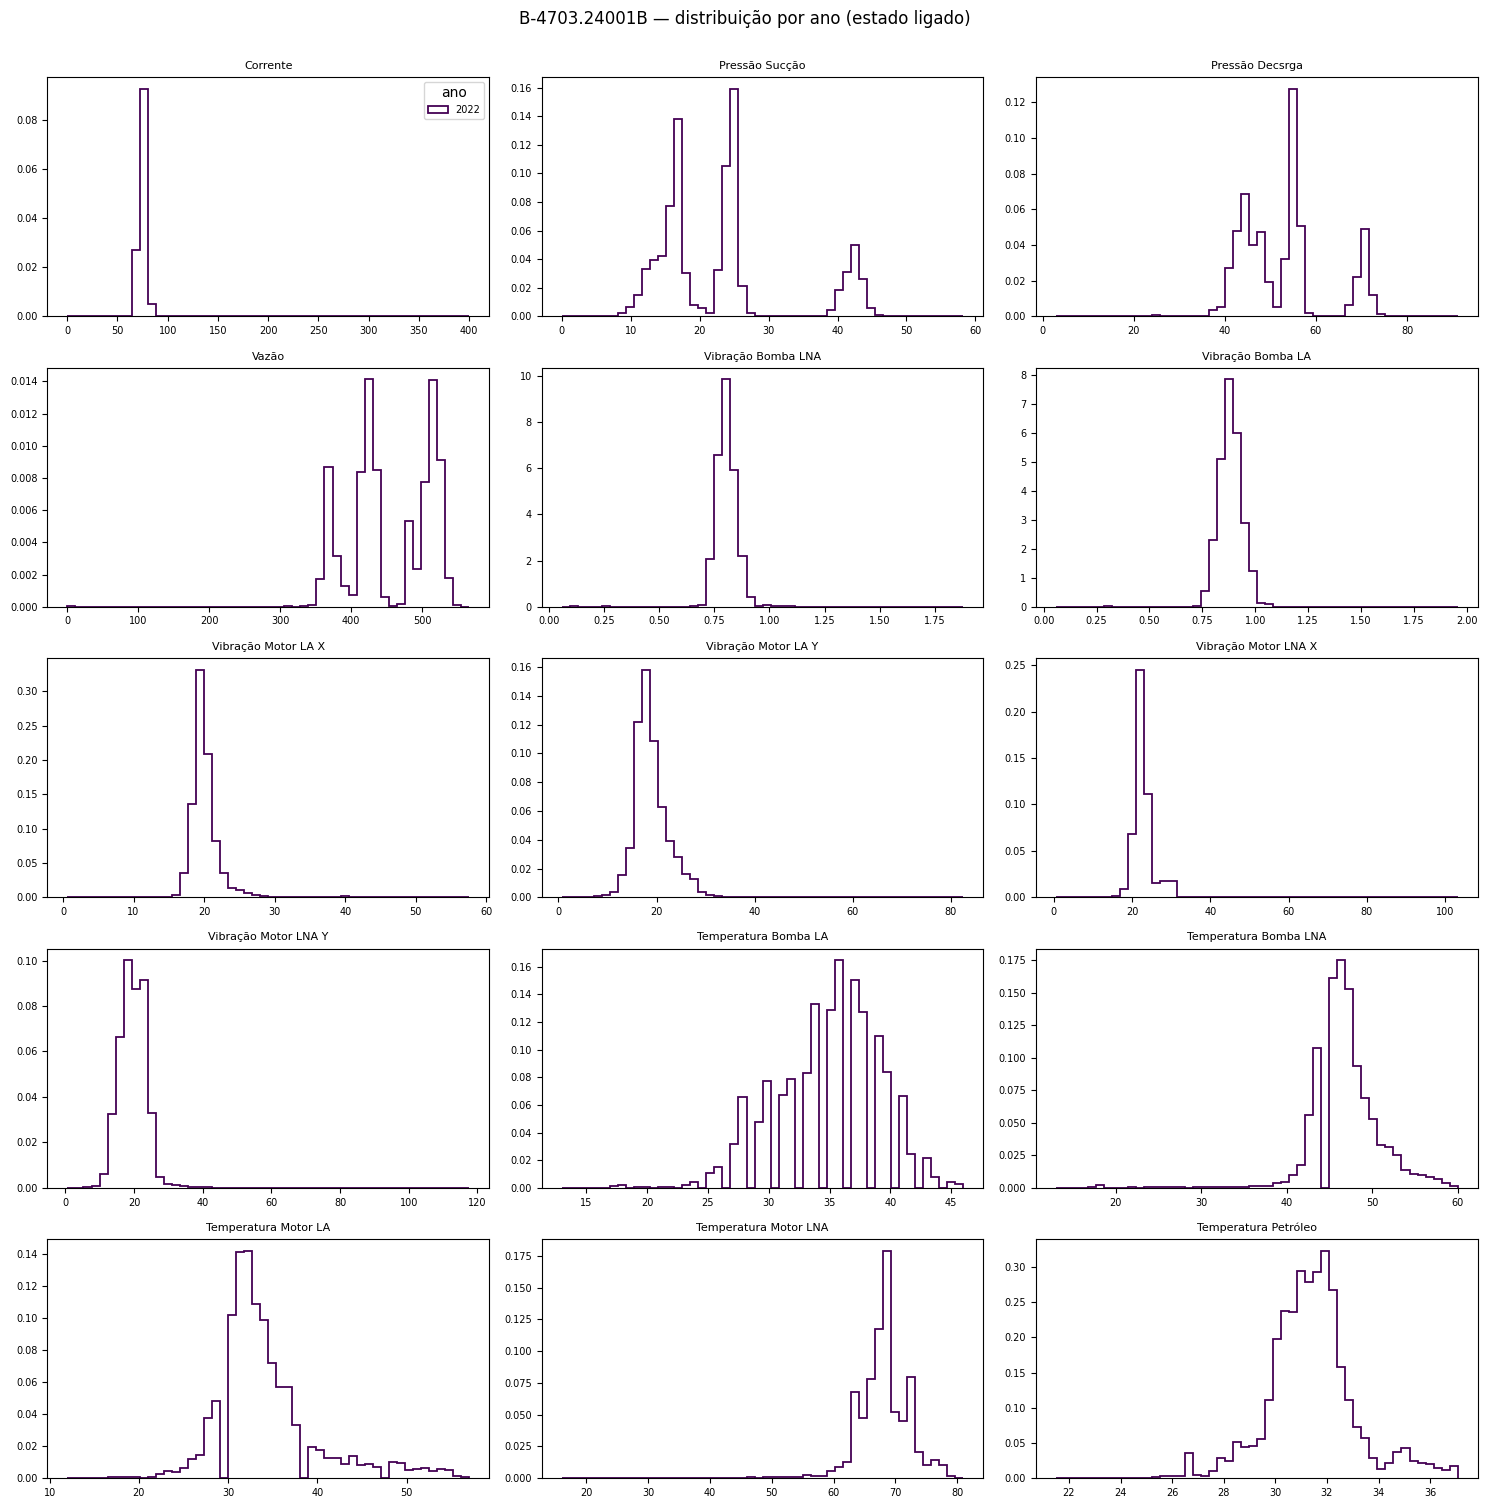

  média por ano (estado ligado):
                         2022
Corrente                74.93
Pressão Sucção          23.13
Pressão Decsrga         52.76
Vazão                  454.94
Vibração Bomba LNA       0.80
Vibração Bomba LA        0.89
Vibração Motor LA X     20.15
Vibração Motor LA Y     19.00
Vibração Motor LNA X    22.86
Vibração Motor LNA Y    19.60
Temperatura Bomba LA    35.00
Temperatura Bomba LNA   46.83
Temperatura Motor LA    34.18
Temperatura Motor LNA   67.94
Temperatura Petróleo    31.42

B-4064A-prod — 43220 linhas x 8 sensores vivos (0 mortos: []) | 2024-01-01 -> 2026-03-27 | falha 2024-08-30


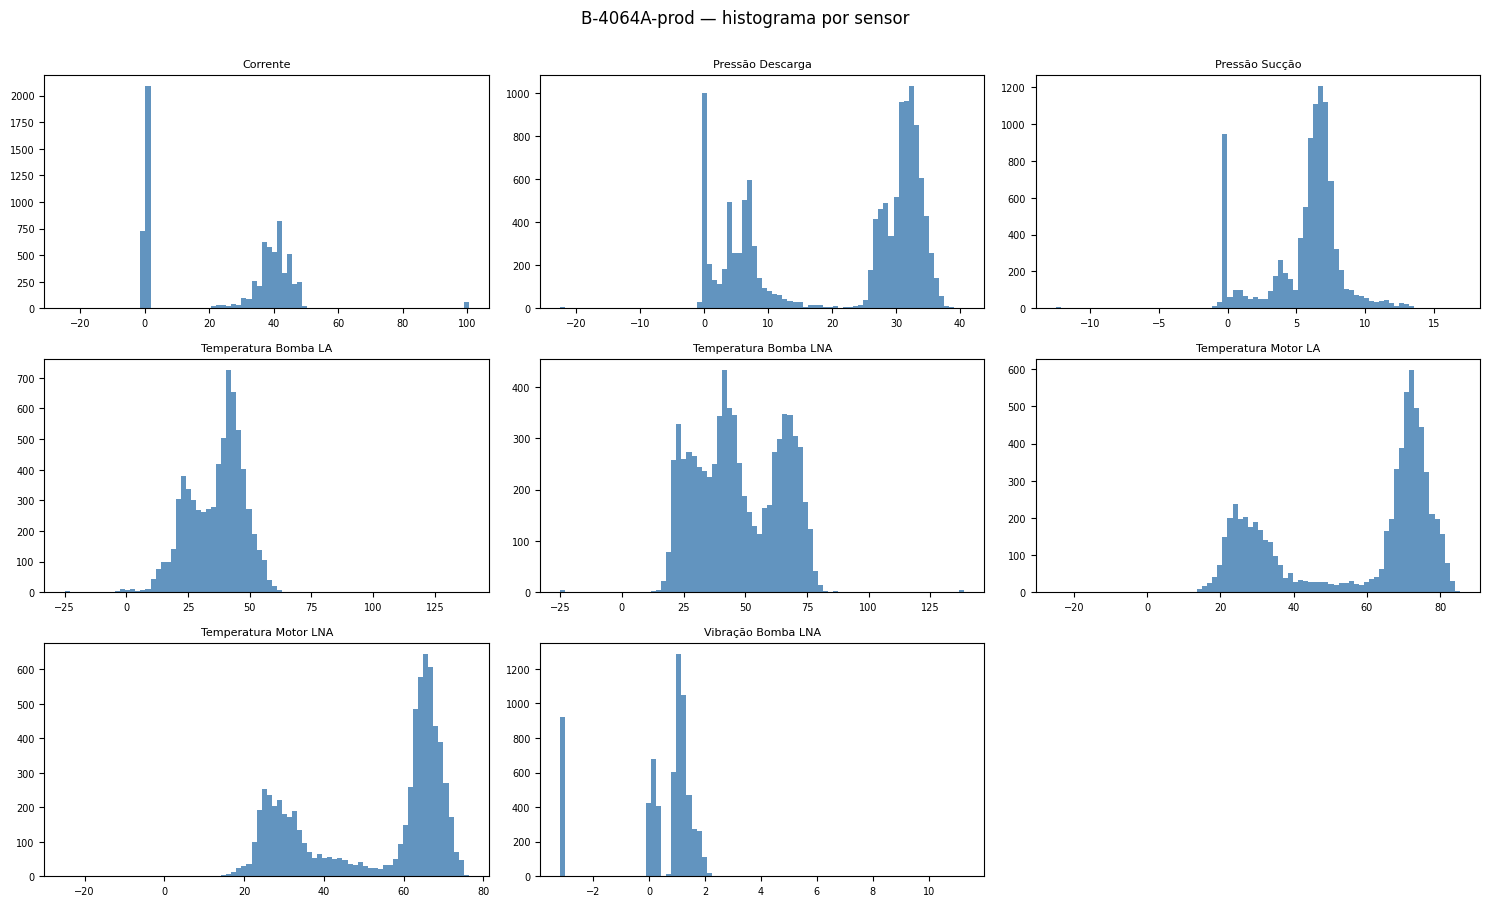

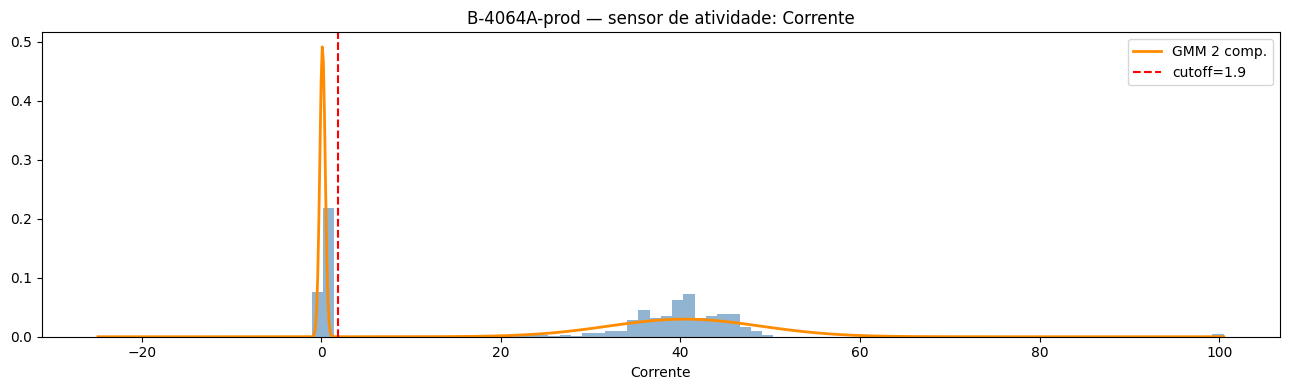

  BIMODAL: modos 0.128 (desligado) / 40.4 (ligado) | cutoff 1.905 | DESLIGADO = 37.0% das leituras válidas


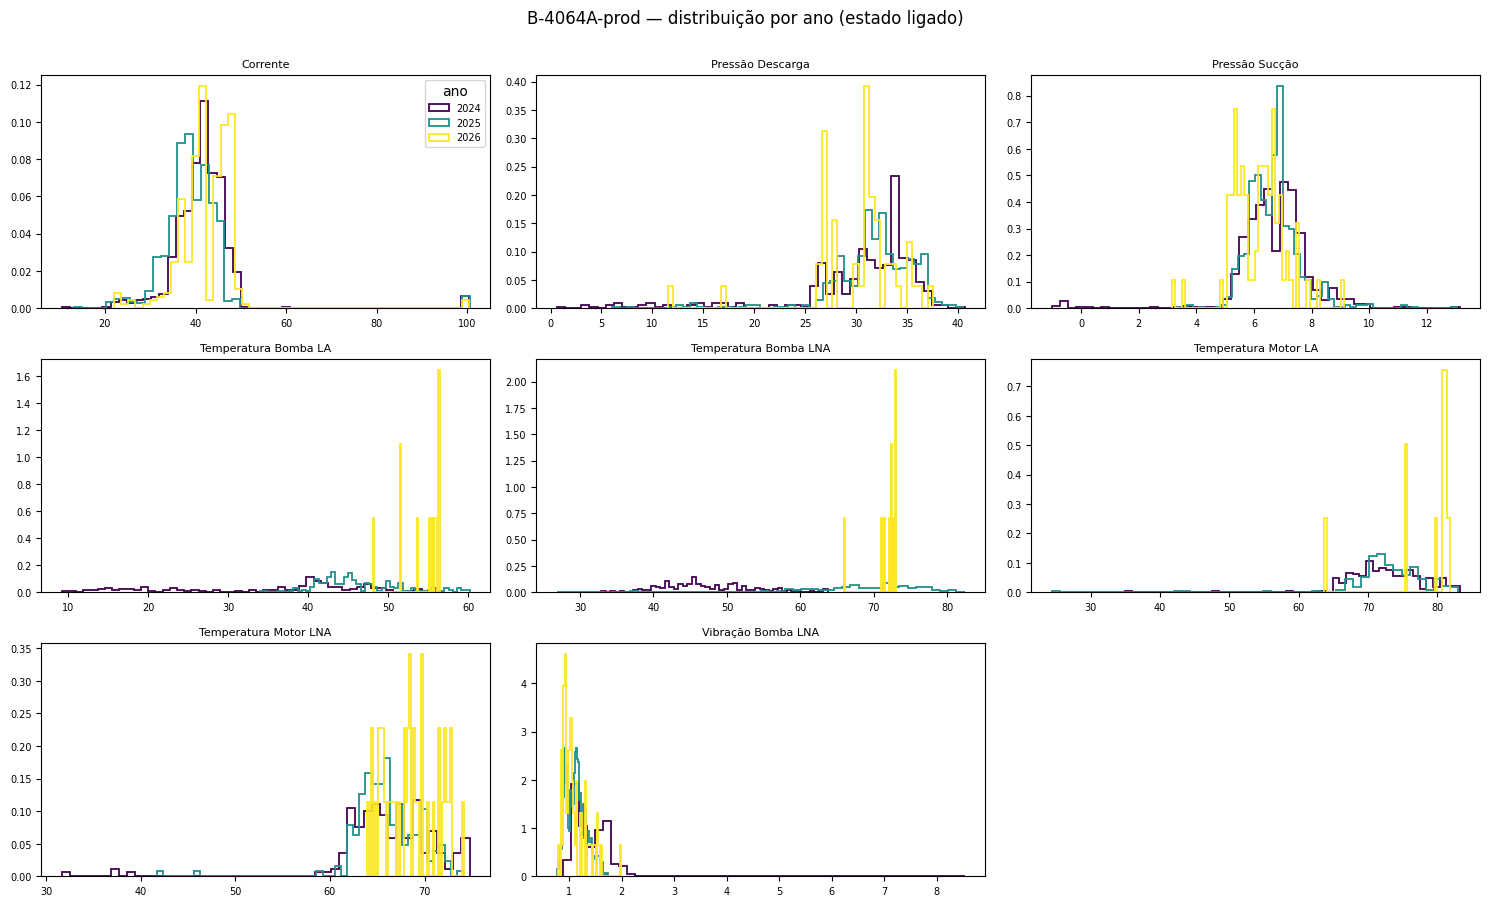

  média por ano (estado ligado):
                        2024   2025   2026
Corrente               41.51  39.37  42.48
Pressão Descarga       30.16  31.67  30.15
Pressão Sucção          6.70   6.68   6.16
Temperatura Bomba LA   35.24  46.33  54.23
Temperatura Bomba LNA  47.30  68.29  71.73
Temperatura Motor LA   72.48  72.88  78.37
Temperatura Motor LNA  66.17  65.99  68.49
Vibração Bomba LNA      1.43   1.14   1.11


In [3]:
resumo = [analisar(eq, falha) for eq, falha in EQUIPS]

In [4]:
# Resumo consolidado
print(f"{'equip':16} {'sensor atividade':24} {'mortos':7} {'bimodal':8} {'% desligado':12} cutoff")
for r in resumo:
    off = f"{100*r['off_frac']:.0f}%" if r['off_frac'] is not None else '—'
    cut = f"{r['cutoff']:.3g}" if r['cutoff'] is not None else '—'
    print(f"{r['eq']:16} {r['activity'][:24]:24} {r['dead']:<7} {str(r['bimodal']):8} {off:12} {cut}")

equip            sensor atividade         mortos  bimodal  % desligado  cutoff
B-0302C          Corrente Media Motor     21      True     93%          73
B-4703.24001B    Corrente                 0       True     76%          0.15
B-4064A-prod     Corrente                 0       True     37%          1.9
